# Cross validation of quantile models for phi

In [ ]:
import sys
import os
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

## Load data

In [ ]:
gpr_cv = pd.read_csv("../_temp/quantiles_cv.GPR_phi.csv").values
cgmtgpqr_cv = pd.read_csv("../_temp/quantiles_cv.CenterGapMTGPQR_phi.csv").values

## Plot

In [ ]:
def sci_label(value: float, precision: int = 2) -> str:
    if value == 0:
        return f"{0:.{precision}f} × 10^0"
    exponent = math.floor(math.log10(abs(value)))
    mantissa = value / (10**exponent)
    return f"{mantissa:.{precision}f} × 10^{exponent}"

### CV loss by epoch

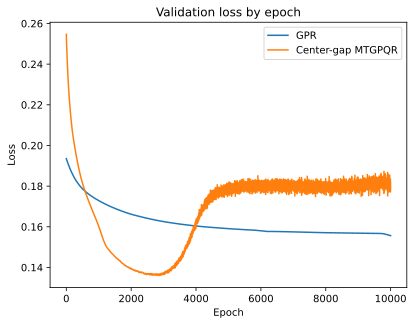

In [ ]:
plt.plot(gpr_cv.mean(axis=1), label="GPR")
plt.plot(cgmtgpqr_cv.mean(axis=1), label="Center-gap MTGPQR")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation loss by epoch")
plt.legend()
plt.show()

### Minimum CV loss

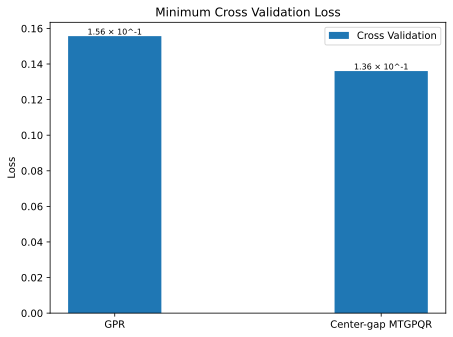

In [ ]:
names = [
    "GPR",
    "Center-gap MTGPQR",
]
cv_losses = [
    gpr_cv.mean(axis=1).min(),
    cgmtgpqr_cv.mean(axis=1).min(),
]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots()
bars_cv = ax.bar(x, cv_losses, width, label="Cross Validation")

for bar in list(bars_cv):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        sci_label(height),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Loss")
ax.set_title("Minimum Cross Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

### Best epoch

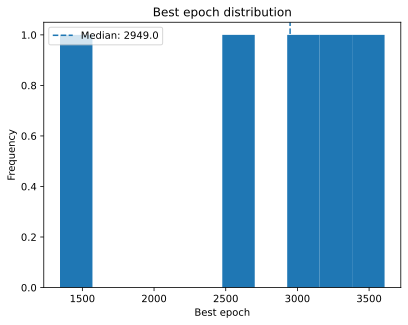

In [ ]:
best_epochs = cgmtgpqr_cv.argmin(axis=0)
median_best_epoch = int(np.median(best_epochs)) + 1

plt.hist(best_epochs)
plt.axvline(median_best_epoch, ls="--", label=f"Median: {median_best_epoch}")

plt.xlabel("Best epoch")
plt.ylabel("Frequency")
plt.title("Best epoch distribution")
plt.legend()
plt.show()